In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import pickle

In [2]:
x = pd.read_csv("mouse5/mouse5_day6.csv", header=None).values

In [3]:
with open("beh.pkl", "rb") as f:
    beh = pickle.load(f)[4][2]
    beh = np.hstack((beh[:, :3], beh[:, 5:] / 40))
with open("w_single.pkl", "rb") as f:
    w = pickle.load(f)[4][2]

Ax value: 30
Ax value: 40


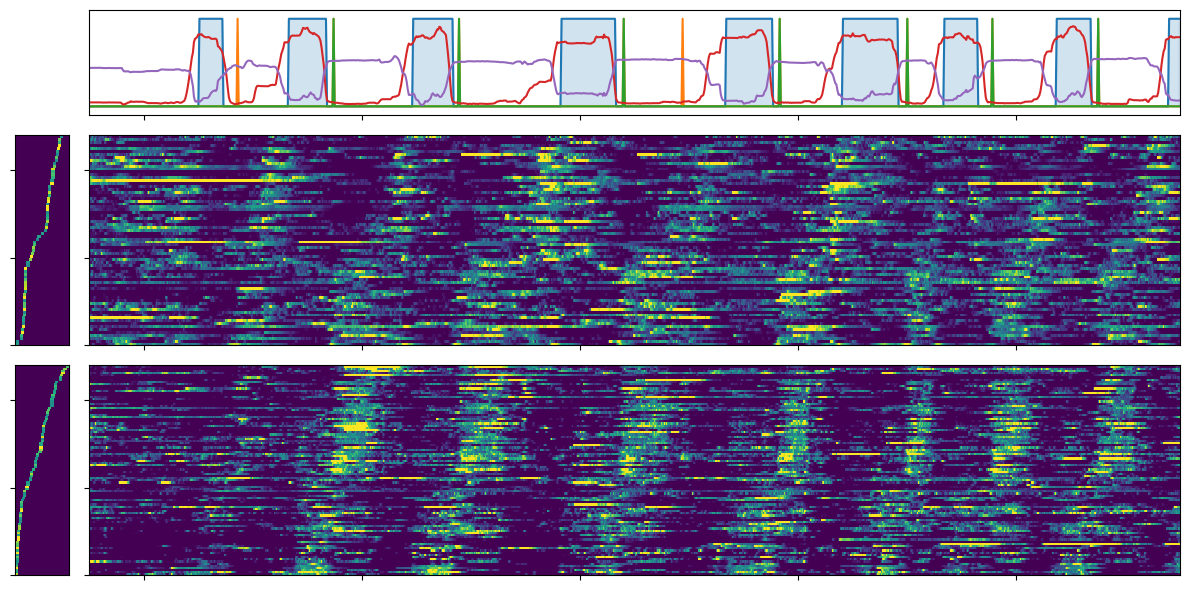

In [4]:
start, length = 7550, 1000
fig, axes = plt.subplots(3, 2, figsize=(12, 6), sharex="col", sharey="row", gridspec_kw={'height_ratios': [1, 2, 2], 'width_ratios': [0.5, 10]})
fig.delaxes(axes[0, 0])
axes[0, 1].plot(beh[start:start+length, :])
axes[0, 1].set_ylim(-0.1, 1.1)
axes[0, 1].tick_params(left=False)
axes[0, 1].fill_between(np.arange(1000), np.zeros(1000), beh[start:start+length, 0], color="C0", alpha=0.2)

def plot_wx(ai, ki):
    wk = w[:, ki, 0]
    th = wk.mean() + wk.std()
    index = np.where(wk > th)[0]
    index = index[w[index, ki, 1].argsort()]
    n = len(index)
    tmp = np.zeros((n, 50))
    for i, (a, p) in enumerate(w[index, ki, :]):
        tmp[i, int(max(0, p-1)):int(p+2)] = a
    axes[ai, 0].pcolor(tmp, vmax=wk.mean() + 3 * wk.std())
    axes[ai, 0].tick_params(labelleft=False, labelbottom=False, bottom=False)
    xk = x[start:start+length, index]
    axes[ai, 1].pcolor(xk.T, vmax=xk.mean() + 3 * xk.std())
    axes[ai, 1].tick_params(labelleft=False, labelbottom=False)
    ax_val = int(n / 20) * 10
    axes[ai, 0].set_yticks([0, ax_val, 2*ax_val])
    print("Ax value: {}".format(ax_val))

plot_wx(1, 1)
plot_wx(2, 4)
axes[2, 1].set_xticks([50, 250, 450, 650, 850])
axes[2, 1].set_xticklabels([1520, 1560, 1600, 1640, 1680])
plt.tight_layout()
plt.savefig("figures/fig3/fig3d.png")

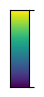

In [5]:
plt.figure(figsize=(0.25, 1))
plt.pcolor(np.linspace(0, 1, 100).reshape(-1, 1))
plt.yticks([0, 100])
plt.tick_params(labelleft=False, labelbottom=False, left=False, bottom=False, right=True)
plt.savefig("figures/fig3/fig3e.png")